# Neural nets

In [1]:
import pandas as pd
import jax
import jax.numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("dark_background")

In [2]:
data = pd.read_csv("sample_data/california_housing_train.csv")
data = pd.DataFrame(data)
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
"Numbers of cols : ",data.shape[1]

('Numbers of cols : ', 9)

In [ ]:
corr = data.corr(numeric_only=True)
target_corr = corr["median_house_value"].sort_values(ascending=False)
target_corr

,median_house_value
median_house_value,1.000000
median_income,0.691871
total_rooms,0.130991
housing_median_age,0.106758
households,0.061031
total_bedrooms,0.045783
population,-0.027850
longitude,-0.044982
latitude,-0.144917


# 5 colunms are selected

In [ ]:
positive_corr = target_corr[(target_corr > 0) & (target_corr < 1)]
positive_corr

,median_house_value
median_income,0.691871
total_rooms,0.130991
housing_median_age,0.106758
households,0.061031
total_bedrooms,0.045783


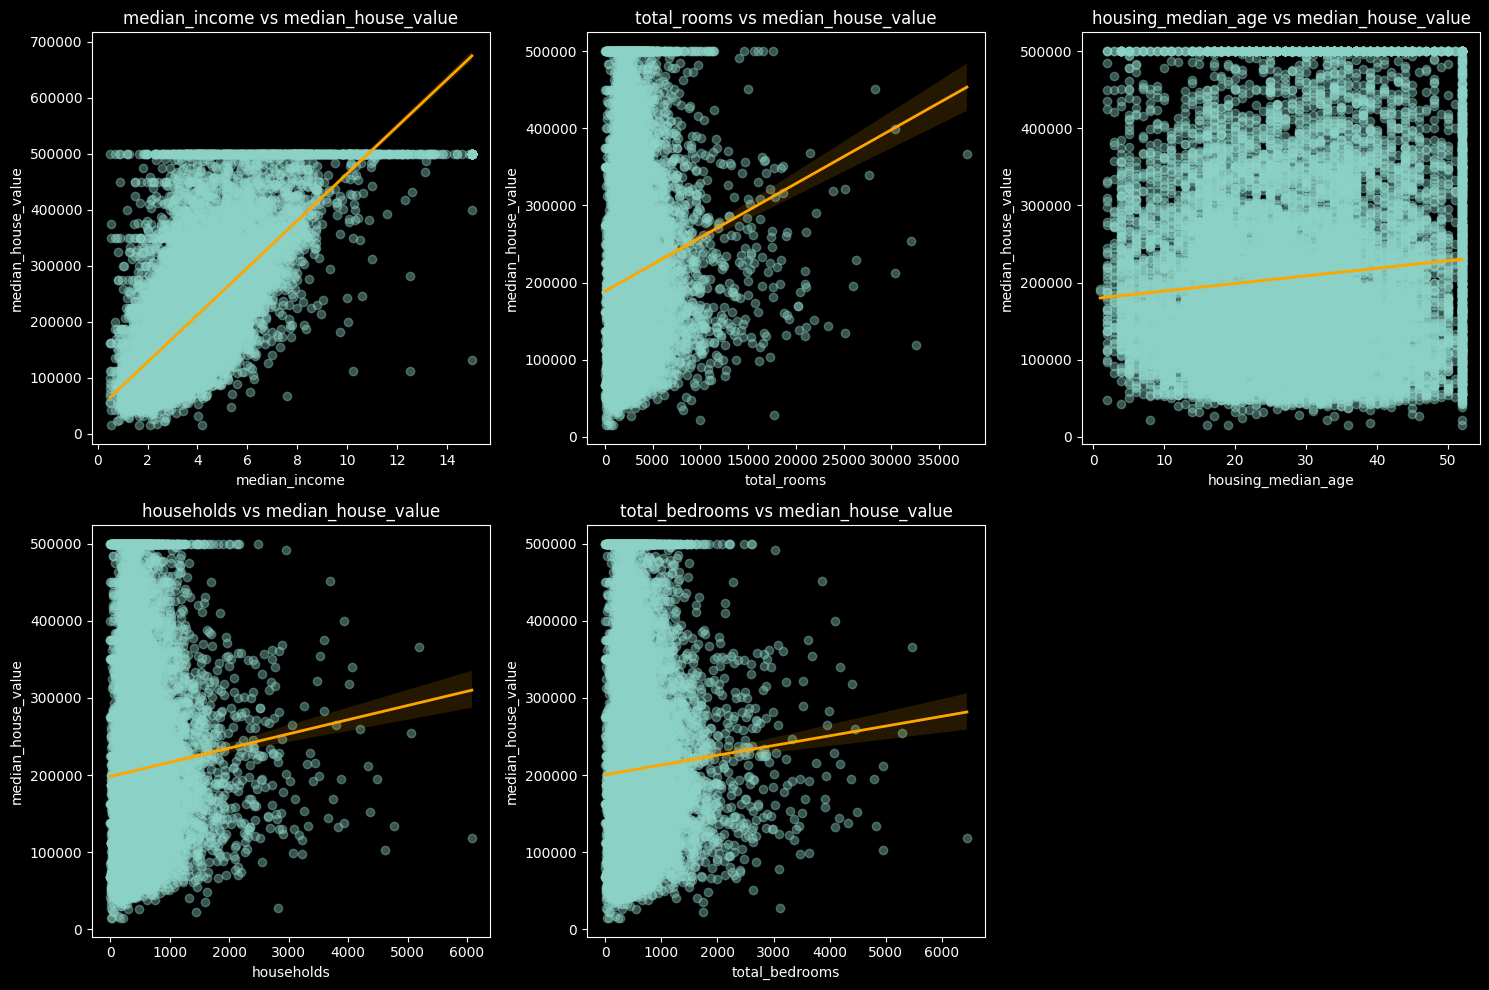

In [ ]:
plt.figure(figsize=(15, 10))
selected_cols = ['median_income', 'total_rooms', 'housing_median_age', 'households', 'total_bedrooms']
for i, col in enumerate(selected_cols, 1):
    plt.subplot(2, 3, i)
    sns.regplot(
        x=data[col],
        y=data['median_house_value'],
        scatter_kws={'alpha': 0.4},
        line_kws={'color': 'orange', 'lw': 2},
    )
    plt.title(f'{col} vs median_house_value')
    plt.xlabel(col)
    plt.ylabel('median_house_value')

plt.tight_layout()
plt.show()

# But Neural nets don't need Pre-process data 😂😂
### Net desine
##  8 → 5 → 1

# Helper function

In [ ]:
def _get_preferred_device(prefer_gpu: bool = True):
    """Return the preferred JAX device (GPU if available, else CPU)."""
    if prefer_gpu:
        gpus = jax.devices("gpu")
        if gpus:
            return gpus[0]
    return jax.devices()[0]

def create_random_matrix(x: int, y: int, low: float = 0.0, high: float = 2.0,
                         dtype=np.float32, key=None, device=None):
    """
    Create an x-by-y JAX array of random floats uniformly sampled in [low, high].

    Args:
      x, y: matrix dimensions
      low, high: range for random values
      dtype: jnp dtype (default: float32)
      key: optional jax.random.PRNGKey
      device: optional jax device (defaults to GPU if available)

    Returns:
      JAX array on chosen device
    """
    if key is None:
        key = jax.random.PRNGKey(0)  # deterministic seed if none given
    if device is None:
        device = _get_preferred_device(prefer_gpu=True)

    # uniform random floats in [low, high)
    arr = jax.random.uniform(key, (x, y), minval=low, maxval=high, dtype=dtype)
    arr = jax.device_put(arr, device=device)
    return arr


def get_row(df: pd.DataFrame, index: int):
    """
    Return a single row as an (n x 1) NumPy matrix (column vector).
    """
    row = df.iloc[index].to_numpy().reshape(-1, 1)
    return row

def forward_pass(weight: np.ndarray, X: np.ndarray, bias: np.ndarray):
    """
    Perform a forward pass: Y = Wᵀ * X + b
    """
    Y = np.dot(weight.T, X) + bias
    return Y

def Loss_funtion(ypred,yorg):
  return np.mean((ypred-yorg)**2)

def relu(x): return np.maximum(0, x)
def sigmoid(x): return 1 / (1 + np.exp(-x))

def model_loss(weight1, bias1, weight2, bias2, X, y_true):
    # Forward through first layer
    hidden = forward_pass(weight1, X, bias1)
    hidden = relu(hidden)     # optional activation (helps gradient flow)

    # Forward through second layer
    y_pred = forward_pass(weight2, hidden, bias2)

    # Compute MSE loss
    return Loss_funtion(y_pred, y_true)

def backprop(weight1, bias1, weight2, bias2, X, y_true):
    grad_fn = jax.grad(model_loss, argnums=(0, 1, 2, 3))
    dW1, dB1, dW2, dB2 = grad_fn(weight1, bias1, weight2, bias2, X, y_true)
    return dW1, dB1, dW2, dB2

def update_WB(dW1, dB1, dW2, dB2, lr=0.001):
    """
    Update global weight and bias variables using gradient descent.

    """
    global weight, bais, weight2, bais2

    weight  -= lr * dW1
    bais    -= lr * dB1
    weight2 -= lr * dW2
    bais2   -= lr * dB2


# First pass


*   Weight
*   Bais



In [ ]:
# For weight matrix we need number of input(8) x number of hidden neurons(5)
weight = create_random_matrix(8, 5, low=0.0, high=2.0, key=jax.random.PRNGKey(42))
print("weight matrix :\n", weight);print("\n")

# For bais matrix we need number of hidden neurons(5)
bais = create_random_matrix(5, 1, low=0.0, high=2.0, key=jax.random.PRNGKey(41))
print("bais matrix :\n", bais);print()

# Input matrix
X = get_row(data, 0)
X = (X - np.mean(X)) / np.std(X)  # standardization
target = X[-1, 0]   # get last value
X = X[:-1, :]
print("Target is : ",target)
print("\nInput matrix :\n", X)

weight matrix :
 [[0.97741914 1.3595943  1.232543   1.1220322  0.9012892 ]
 [1.1717317  0.14961886 1.5502667  1.3979185  1.6372674 ]
 [0.7006104  1.74564    1.8517628  1.7202613  0.95510817]
 [1.6369636  1.422709   1.1733944  0.14747477 1.5552444 ]
 [0.80913115 0.23824644 0.05251122 1.2783575  0.8094623 ]
 [1.7756824  0.16294885 0.5928097  1.2133594  1.8764699 ]
 [1.5120158  0.9172671  0.6154516  1.5017104  1.0882647 ]
 [0.7280283  1.3508208  1.180228   0.5774965  0.37723017]]


bais matrix :
 [[1.8581407 ]
 [0.05586457]
 [0.5610788 ]
 [0.54276156]
 [1.6058674 ]]

Target is :  2.8190262

Input matrix :
 [[-0.40795267]
 [-0.40080184]
 [-0.40172595]
 [-0.13221036]
 [-0.3406672 ]
 [-0.35357237]
 [-0.37971976]
 [-0.40237632]]


In [ ]:
data.head(1)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0


In [ ]:
# First pass
_2nd_X = forward_pass(weight, X, bais)
print("Output (2nd Input):\n", _2nd_X)
print("Shape:", _2nd_X.shape)

Output (2nd Input):
 [[-1.2786696]
 [-2.4787385]
 [-2.3982112]
 [-2.852939 ]
 [-1.5115962]]
Shape: (5, 1)


Second pass
*   Weight
*   Bais

In [ ]:
weight2 = create_random_matrix(5, 1, low=0.0, high=2.0, key=jax.random.PRNGKey(40))
print("weight matrix :\n", weight2);print("\n")
bais2 = create_random_matrix(1, 1, low=0.0, high=2.0, key=jax.random.PRNGKey(39))
print("bais matrix :\n", bais2);print()

weight matrix :
 [[0.31392717]
 [0.8373921 ]
 [0.46402907]
 [0.6304095 ]
 [0.38634467]]


bais matrix :
 [[0.6256037]]



In [ ]:
y = forward_pass(weight2, _2nd_X, bais2)
print("Output (2nd Input):\n", y)
print("Shape:", y.shape)


Output (2nd Input):
 [[-5.346838]]
Shape: (1, 1)


In [ ]:
print("Training loss : ",Loss_funtion(y,target))

Training loss :  66.681335


In [ ]:
y_true = np.array([[target]], dtype=np.float32)

# compute gradients
dW1, dB1, dW2, dB2 = backprop(weight, bais, weight2, bais2, X, y_true)

print("Grad shapes:")
print("dW1:", dW1.shape)
print("dB1:", dB1.shape)
print("dW2:", dW2.shape)
print("dB2:", dB2.shape)

Grad shapes:
dW1: (8, 5)
dB1: (5, 1)
dW2: (5, 1)
dB2: (1, 1)


In [ ]:
# update global weights/biases
update_WB(dW1, dB1, dW2, dB2, lr=0.001)

# optional: print updated loss
y_pred = forward_pass(weight2, relu(forward_pass(weight, X, bais)), bais2)
loss = Loss_funtion(y_pred, np.array([[target]]))
print(loss)

4.7918773


Working fine
# How create a single and easy to use function


---

# Neural Network code
Neural Network Architecture

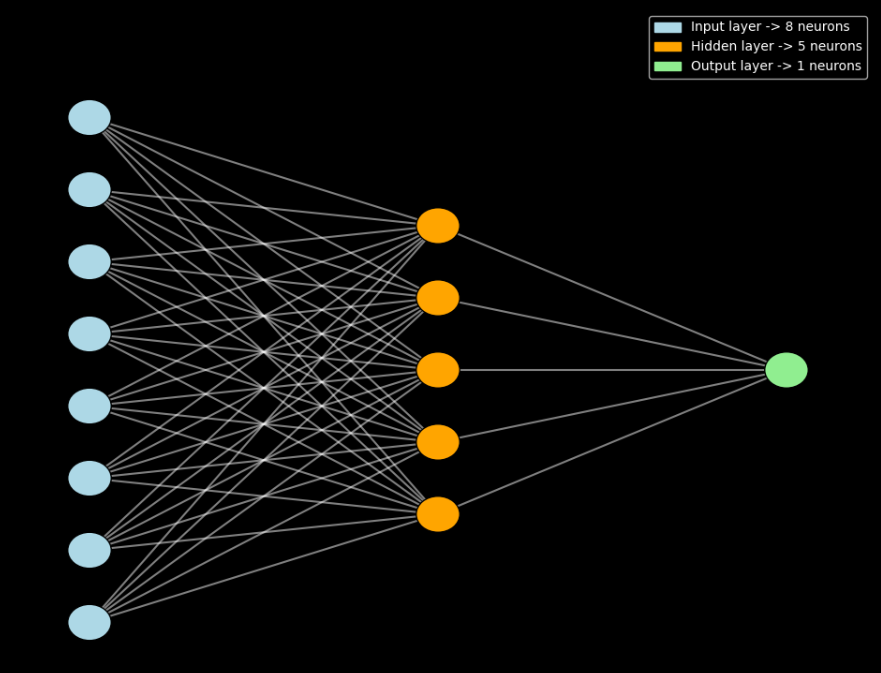

In [3]:
import jax
import jax.numpy as jnp
from sklearn.preprocessing import StandardScaler
import numpy as np
from typing import Callable, List

# -----------------------------
# Activation functions
# -----------------------------
def relu(x):
    return jnp.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + jnp.exp(-x))

# -----------------------------
# Utility functions
# -----------------------------
def _get_preferred_device(prefer_gpu: bool = True):
    """Return the preferred JAX device (GPU if available, else CPU)."""
    if prefer_gpu:
        gpus = jax.devices("gpu")
        if gpus:
            return gpus[0]
    return jax.devices()[0]

def create_random_matrix(x: int, y: int, low: float = 0.0, high: float = 2.0,
                         dtype=jnp.float32, key=None, device=None):
    """Create x-by-y JAX array with uniform random floats"""
    if key is None:
        key = jax.random.PRNGKey(0)
    if device is None:
        device = _get_preferred_device(prefer_gpu=True)
    arr = jax.random.uniform(key, (x, y), minval=low, maxval=high, dtype=dtype)
    arr = jax.device_put(arr, device=device)
    return arr

def forward_pass(weight, X, bias):
    """Forward pass: W^T * X + b"""
    return jnp.dot(weight.T, X) + bias

def Loss_funtion(ypred, yorg):
    """MSE Loss using jax.numpy"""
    return jnp.mean((ypred - yorg) ** 2)

# -----------------------------
# Backpropagation
# -----------------------------
def model_loss(weight1, bias1, weight2, bias2, X, y_true, act_fun):
    hidden = forward_pass(weight1, X, bias1)
    hidden = act_fun(hidden)
    y_pred = forward_pass(weight2, hidden, bias2)
    return Loss_funtion(y_pred, y_true)

def backprop(weight1, bias1, weight2, bias2, X, y_true, act_fun):
    grad_fn = jax.grad(model_loss, argnums=(0,1,2,3))
    dW1, dB1, dW2, dB2 = grad_fn(weight1, bias1, weight2, bias2, X, y_true, act_fun)
    return dW1, dB1, dW2, dB2

def update_WB(dW1, dB1, dW2, dB2, lr=0.001):
    """Update global weight/bias variables in-place"""
    global weight, bais, weight2, bais2
    weight  -= lr * dW1
    bais    -= lr * dB1
    weight2 -= lr * dW2
    bais2   -= lr * dB2

# -----------------------------
# Neural Network Training
# -----------------------------
def Personal_NN(X: jnp.ndarray, y_org: jnp.ndarray, lr: float = 0.001,
                epochs: int = 10, act_fun: Callable = relu,
                num_epo_print: int = 1) -> List[jnp.ndarray]:
    """
    Simple 2-layer NN with customizable activation function for hidden layer.

    Args:
        X: Input column vector (n x 1)
        y_org: Target scalar (standardized)
        lr: Learning rate
        epochs: Number of training epochs
        act_fun: Activation function for hidden layer (callable)
        num_epo_print: Print loss every `num_epo_print` epochs

    Returns:
        weight, bais, weight2, bais2
    """
    global weight, bais, weight2, bais2
    # Initialize weights and biases
    weight  = create_random_matrix(8, 5, key=jax.random.PRNGKey(42))
    bais    = create_random_matrix(5, 1, key=jax.random.PRNGKey(41))
    weight2 = create_random_matrix(5, 1, key=jax.random.PRNGKey(40))
    bais2   = create_random_matrix(1, 1, key=jax.random.PRNGKey(39))

    # Initial forward pass
    hidden = forward_pass(weight, X, bais)
    hidden = act_fun(hidden)
    y_pred = forward_pass(weight2, hidden, bais2)
    if num_epo_print > 0:
        print("Initial Training loss:", np.array(Loss_funtion(y_pred, y_org)))

    for epoch in range(epochs):
        dW1, dB1, dW2, dB2 = backprop(weight, bais, weight2, bais2, X, y_org, act_fun)
        update_WB(dW1, dB1, dW2, dB2, lr)

        if num_epo_print > 0 and ((epoch+1) % num_epo_print == 0 or epoch == epochs-1):
            hidden = forward_pass(weight, X, bais)
            hidden = act_fun(hidden)
            y_pred = forward_pass(weight2, hidden, bais2)
            loss = Loss_funtion(y_pred, y_org)
            print(f"Epoch {epoch+1} Training loss:", np.array(loss))

    return weight, bais, weight2, bais2

# -----------------------------
# Prediction
# -----------------------------
def predict(X, weight1, bias1, weight2, bias2, act_fun: Callable = relu,
            scaler_y=None):
    hidden = forward_pass(weight1, X, bias1)
    hidden = act_fun(hidden)
    y_pred_std = forward_pass(weight2, hidden, bias2)

    if scaler_y is not None:
        # reshape to 2D for StandardScaler
        y_pred_std_np = np.array(y_pred_std).reshape(-1, 1)
        y_pred_original = scaler_y.inverse_transform(y_pred_std_np)
        return y_pred_original[0,0]   # return scalar
    else:
        return y_pred_std




## Test Network on single Row

In [ ]:
# -----------------------------
# Example Usage
# -----------------------------
# Original data
X = np.array([[-114.31], [34.19], [15.0], [5612.0], [1283.0], [1015.0], [472.0], [1.4936]])
y = np.array([[66900.0]])

# Standardize input
scaler_X = StandardScaler()
X_std = scaler_X.fit_transform(X)

# Standardize target
scaler_y = StandardScaler()
y_std = scaler_y.fit_transform(y)

# Convert to JAX arrays
X_jax = jnp.array(X_std, dtype=jnp.float32)
y_jax = jnp.array(y_std[0,0], dtype=jnp.float32)

# Train
weight, bais, weight2, bais2 = Personal_NN(X_jax, y_jax, lr=0.001, epochs=100,
                                            act_fun=relu, num_epo_print=10)

# Predict
y_pred_original = predict(X_jax, weight, bais, weight2, bais2, act_fun=relu, scaler_y=scaler_y)
print("\nNN prediction :", y_pred_original)


Initial Training loss: 12.134427
Epoch 10 Training loss: 3.6162503
Epoch 20 Training loss: 1.1879065
Epoch 30 Training loss: 0.45228496
Epoch 40 Training loss: 0.19503677
Epoch 50 Training loss: 0.084053725
Epoch 60 Training loss: 0.03615881
Epoch 70 Training loss: 0.015527253
Epoch 80 Training loss: 0.006658129
Epoch 90 Training loss: 0.0028520352
Epoch 100 Training loss: 0.0012207726

NN prediction : 66900.03


In [ ]:
data.head(1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0


## Train Nerual Network on california_housing_train

In [4]:
# -----------------------------
# Load California housing dataset from Google Colab
# -----------------------------
import pandas as pd

# Load CSV
data_path = "/content/sample_data/california_housing_train.csv"
df = pd.read_csv(data_path)

# Separate features (X) and target (y)
X = df.drop(columns=["median_house_value"]).values
y = df["median_house_value"].values.reshape(-1, 1)

# Standardize input and target
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_std = scaler_X.fit_transform(X)
y_std = scaler_y.fit_transform(y)

# Convert to JAX arrays (transpose so each column = one feature vector)
X_jax = jnp.array(X_std.T, dtype=jnp.float32)
y_jax = jnp.array(y_std.T, dtype=jnp.float32)

# -----------------------------
# Train on full dataset
# -----------------------------
weight, bais, weight2, bais2 = Personal_NN(
    X_jax, y_jax,
    lr=0.01,
    epochs=50000,
    act_fun=relu,
    num_epo_print=10000
)

# -----------------------------
# Predict on some samples
# -----------------------------
print("\n--- Predictions ---")
for i in range(5):
    x_sample = X_std[i].reshape(-1, 1)   # single column vector
    x_sample_jax = jnp.array(x_sample, dtype=jnp.float32)
    y_pred_original = predict(x_sample_jax, weight, bais, weight2, bais2, act_fun=relu, scaler_y=scaler_y)
    print(f"Row {i} | Predicted: {y_pred_original:.2f} | Actual: {y[i,0]:.2f}")


Initial Training loss: 79.83416
Epoch 10000 Training loss: 0.3372166
Epoch 20000 Training loss: 0.31948
Epoch 30000 Training loss: 0.3121385
Epoch 40000 Training loss: 0.30813605
Epoch 50000 Training loss: 0.2984146

--- Predictions ---
Row 0 | Predicted: 26485.10 | Actual: 66900.00
Row 1 | Predicted: 66966.23 | Actual: 80100.00
Row 2 | Predicted: 21996.21 | Actual: 85700.00
Row 3 | Predicted: 36700.12 | Actual: 73400.00
Row 4 | Predicted: 19030.13 | Actual: 65500.00


In [ ]:
# Epoch 1000 Training loss: 0.74642926 < - relu
# Epoch 1000 Training loss: 0.856182 < - segmoid